In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../crisp_py')

from core import *
from photonuclear_cross_sections import *

# Creating interaction core

The main class is InteractionCore which implements the computation of interaction rates, the probability distribution functions, and utility functions to get the parameters for the distributions.

In [ ]:
!git clone https://github.com/CRPropa/CRPropa3-data.git

In [ ]:
crp_xsec_high = CRPropa_model(path='CRPropa3-data/tables/PD_Talys1.8_Khan')
crp_xsec_low = CRPropa_model(path='CRPropa3-data/tables/PD_external')

xsec_mr = Model_Rack(models=(crp_xsec_low, crp_xsec_high))

In [ ]:
ic = InteractionCore_CRPdata_CMB(xsec_model=xsec_mr)

# Illustrating how the injection composition changes the distribution
## Some parameters needed: boost values and distances for the distributions

In [ ]:
br = np.logspace(10, 10.5, 2)
distances = np.logspace(-1.5, 2.1, 60)
boostidx = 0

alpha, mr, tr, _ = ic.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only mass', [1]))

## Example 1: UHECR-like composition

In [ ]:
alpha1 = np.zeros_like(alpha)
# injection based on PAO best fit 2017
alpha1[ic.species.index((14, 28))] = .046
alpha1[ic.species.index((7, 14))] = .281
alpha1[ic.species.index((2, 4))] = .673

boosts, total1 = ic.pdf_boost_range(distances, alpha1, mass_range=mr, boost_range=br, true_range=tr)

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
plt.semilogx(distances, total1[boostidx, :], label='only surrogates', c='grey')
plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')

plt.sca(axes[1])

z = np.array([ic.species[k][0] for k in mr])
a = np.array([ic.species[k][1] for k in mr])

plt.scatter(a-z, z, s=90, marker='s', ec='grey', fc='none')

cmap = plt.get_cmap('Greens')
plt.scatter(a-z, z, s=70, marker='s', c=100*alpha1, ec='none', cmap=cmap)
plt.colorbar(label='Relative abundance [arb. units]')

plt.xlabel('Neutron number');
plt.ylabel('Proton number');

## Example 2: All species equally

In [ ]:
# injecting all species in mass groups equally
alpha2 = np.zeros_like(alpha)
alpha2[ic.species.index((26, 56)):ic.species.index((2, 4))] = 1 / (ic.species.index((2, 4)) - ic.species.index((26, 56)))

boosts, total2 = ic.pdf_boost_range(distances, alpha2, mass_range=mr, boost_range=br, true_range=tr)

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
plt.semilogx(distances, total2[boostidx, :], label='all masses', ls='--', c='k')
plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')

plt.sca(axes[1])

z = np.array([ic.species[k][0] for k in mr])
a = np.array([ic.species[k][1] for k in mr])

plt.scatter(a-z, z, s=90, marker='s', ec='grey', fc='none')

cmap = plt.get_cmap('Greens')
plt.scatter(a-z, z, s=70, marker='s', c=100*alpha2, ec='none', cmap=cmap)
plt.colorbar(label='Relative abundance [%]')

plt.xlabel('Neutron number');
plt.ylabel('Proton number');

## Example 3: Solar abundances

Text(0, 0.5, 'Relative abundance [arb. units]')

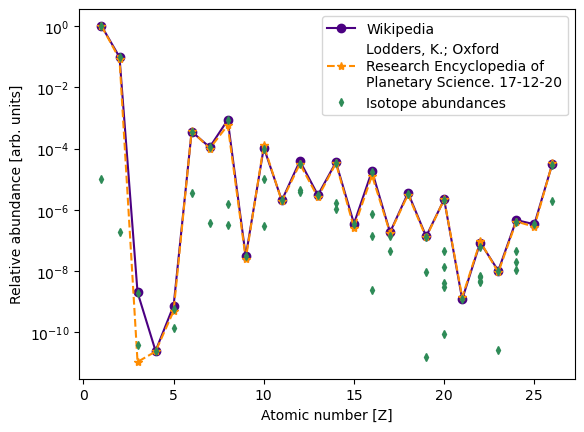

In [ ]:
from pandas import read_csv
chem_abund_1 = read_csv('../data/Chemical_abundances.csv', header=1, names=['Z', 'dens']) # relative to silicon
chem_abund_2 = read_csv('../data/Atomic_abundances.csv', header=3, names=['Z', 'val', 'err'])
elem_abund = read_csv('../data/isotope_relative_abundances.csv', header=1, names=['Z', 'A', 'min', 'max'])

chem_abund_1['dens'] /= chem_abund_1['dens'].sum()

abund = lambda val: 10**(val - 12)
chem_abund_2['val'] = chem_abund_2['val'].apply(abund)


plt.plot(chem_abund_1['Z'], chem_abund_1['dens'] / chem_abund_1['dens'][0], '-o', c='indigo', label='Wikipedia')
plt.plot(chem_abund_2['Z'], chem_abund_2['val'], '--*', c='darkorange', label='Lodders, K.; Oxford\nResearch Encyclopedia of\nPlanetary Science. 17-12-20')

eabund = np.hstack([chem_abund_1.loc[chem_abund_1['Z'] == Zval]['dens'].values for Zval in elem_abund['Z']])
plt.plot(elem_abund['Z'], elem_abund['min'] * eabund / chem_abund_1['dens'][0], '-d', c='seagreen', ms=4, lw=0, label='Isotope abundances')

plt.semilogy()
plt.legend()
plt.xlabel('Atomic number [Z]')
plt.ylabel('Relative abundance [arb. units]')

In [ ]:
# injecting according to solar system abundances
alpha3 = np.zeros_like(alpha)

for idx, (Z, A) in enumerate(ic.species):
    if Z <= 1:
        continue
    
    chem_ab = chem_abund_1[chem_abund_1['Z'] == Z]['dens']
    elem_ab = elem_abund.loc[np.logical_and(elem_abund['Z'] == Z, elem_abund['A'] == A)][['min', 'max']]
    elem_ab = elem_ab.values[np.logical_not(np.isnan(elem_ab.values))]

    if elem_ab.size == 0:
        elem_ab = [0]

    alpha3[idx] = float(((chem_ab * min(elem_ab))).iloc[0])

alpha3 /= sum(alpha3)

boosts, total3 = ic.pdf_boost_range(distances, alpha3, mass_range=mr, boost_range=br, true_range=tr)

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
plt.semilogx(distances, total3[boostidx, :], label='Solar abundances', ls='-.', c='k')

plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')

plt.sca(axes[1])

z = np.array([ic.species[k][0] for k in mr])
a = np.array([ic.species[k][1] for k in mr])

plt.scatter(a-z, z, s=90, marker='s', ec='grey', fc='none')

varalpha = 100*alpha3.copy()
varalpha[varalpha == 0] = None
varalpha = np.log10(varalpha)

cmap = plt.get_cmap('Greens')
plt.scatter(a-z, z, s=70, marker='s', c=varalpha, ec='none', cmap=cmap)
plt.colorbar(label='log Relative abundance [%]')

plt.xlabel('Neutron number');
plt.ylabel('Proton number');

## All examples together

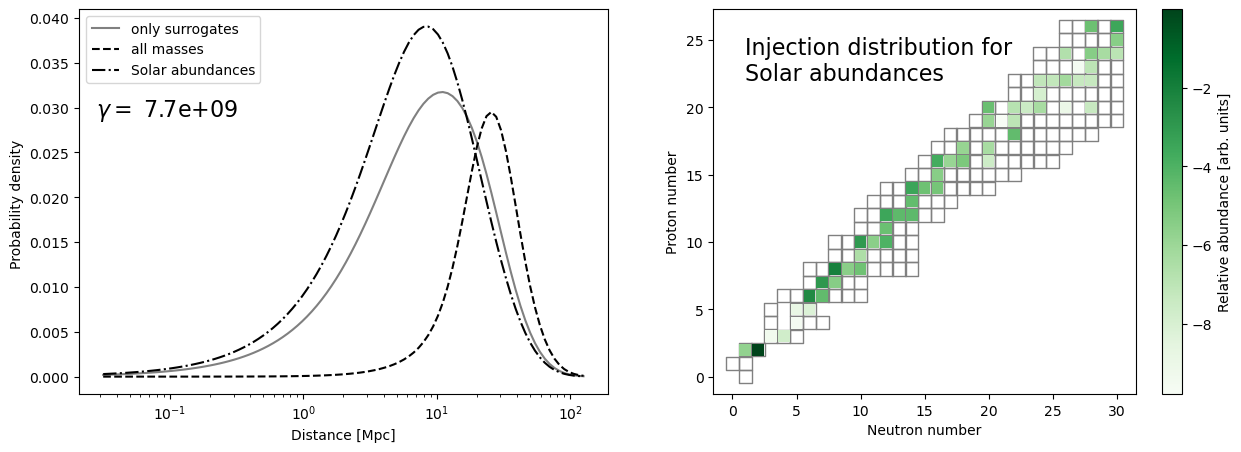

In [ ]:
plt.semilogx(distances, total1[boostidx, :], label='only surrogates', c='grey')
plt.semilogx(distances, total2[boostidx, :], label='all masses', ls='--', c='k')
plt.semilogx(distances, total3[boostidx, :], label='Solar abundances', ls='-.', c='k')

plt.legend()
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')